# Text Preprocessing with Keras

In [1]:
# importing libraries

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D
# import tsensor
import numpy as np

## Tokenization

In [2]:
# Tokenising sentences
sentences = [
    'The quick brown fox jumps over the lazy dog.'
]
tokenizer = Tokenizer()                 # create an instance
tokenizer.fit_on_texts(sentences)       # fit

Tokenizer picks up the unique words from a sentence and assigns an index according to order of appearence in the sentence.

In [ ]:
# Visualizing the sequence
tokenizer.index_word

{1: 'the',
 2: 'quick',
 3: 'brown',
 4: 'fox',
 5: 'jumps',
 6: 'over',
 7: 'lazy',
 8: 'dog'}

In [5]:
train_sequence = np.array(tokenizer.texts_to_sequences(sentences))    # use tokenizer to create word sequence
print(train_sequence)

[[1 2 3 4 5 6 1 7 8]]


textx_to_sequence() assings the word indices in the order of appearence in a given sentence. Using this sequence the original sentence can be retrieved using the word indices created.

In [6]:
# Retrieving original sentence from token and train sequence
' '.join([tokenizer.index_word[seq] for seq in train_sequence[0]])

'the quick brown fox jumps over the lazy dog'

## Creating Embedding Layer

In [7]:
# Create a random embedding layer

embedding = Embedding(input_dim=len(train_sequence[0]), output_dim=128)

Embedding the the input matrix. Embedding allows selection of a word or a group of words according to the input vector and passes it on to the next hidden layer of a neural network. So the dimension of word embedding = (words in corpus x neurons in hidden layer)

In [8]:
# Get the embeddings of the train sample

train_sample = embedding(train_sequence)

In [9]:
train_sequence.shape

(1, 9)

In [10]:
train_sample.shape

TensorShape([1, 9, 128])

In [26]:
# with tsensor.explain(fontname='Hack', dimfontname='Hack'):
#     train_sample = embedding(train_sequence)

In [ ]:
train_sample[0]     # word embedding for a single document

<tf.Tensor: shape=(9, 128), dtype=float32, numpy=
array([[ 0.02173494, -0.03022984,  0.01297773, ...,  0.04587713,
        -0.02881357, -0.00525633],
       [-0.00667759, -0.04342016, -0.02808058, ...,  0.03549061,
         0.04412943,  0.02197898],
       [ 0.01336778, -0.02527693, -0.00547244, ...,  0.02689536,
         0.0253705 ,  0.0392423 ],
       ...,
       [ 0.02173494, -0.03022984,  0.01297773, ...,  0.04587713,
        -0.02881357, -0.00525633],
       [-0.02279013, -0.00446294, -0.0297585 , ...,  0.0115347 ,
         0.00787616, -0.03496242],
       [ 0.04509072, -0.0017374 , -0.02480065, ...,  0.02256343,
         0.03990923, -0.04797136]], dtype=float32)>

In [12]:
train_sample[0, 0].shape

TensorShape([128])

In [13]:
train_sample[0, :, 0].shape

TensorShape([9])

128 is the dimension of each word vector. And there are 9 words.

## Averaging across tokens

In [14]:
GlobalAveragePooling1D()(train_sample)

<tf.Tensor: shape=(1, 128), dtype=float32, numpy=
array([[ 1.64847970e-02, -8.17053020e-03, -1.24689452e-02,
        -1.34374516e-03, -1.54277252e-03, -7.06164865e-03,
        -2.20623389e-02,  2.38392279e-02,  1.56428188e-03,
         1.13916732e-02,  8.51209927e-03, -4.84110601e-03,
         3.42654157e-03, -1.63384769e-02,  1.76061559e-02,
        -1.04984185e-02,  7.25792674e-03,  9.41424072e-03,
        -4.37495485e-03, -7.05578597e-03,  1.58047881e-02,
         4.54916246e-03, -1.54274865e-03, -1.27431098e-02,
        -1.49712793e-03,  8.27360060e-03, -1.81336440e-02,
        -9.43738595e-03,  7.85044488e-03, -3.79673438e-03,
         3.47339455e-03, -6.37037959e-03, -5.93909575e-03,
        -6.96643768e-03,  3.68954777e-03, -7.32716988e-04,
         8.90726410e-03, -4.87289950e-03, -6.91898027e-03,
         1.16112418e-02, -7.87004828e-03, -4.53045033e-03,
        -1.40148057e-02,  5.76669257e-03,  1.79587514e-03,
        -4.02913289e-03, -3.42645589e-03, -1.49797248e-02,
      

![](images/Emb6.png)

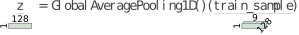

In [ ]:
# with tsensor.explain(fontname='Hack', dimfontname='Hack'):
#     z = GlobalAveragePooling1D()(train_sample)

## Creating Word Embeddings for more than one sentence

In [20]:
# More than one sentence

test_corpus = [
    'The quick brown fox jumps over the lazy dog.',
    'The quick brown fox.',
    'The lazy dog.',
    'The dog.',
    'The dog and the fox.',
    'Hello, world!'
]
encoded_sentences = tokenizer.texts_to_sequences(test_corpus)   # assign sequence of word indices according to occurence

for sentence, encoded_sentence in zip(test_corpus, encoded_sentences):
    print(sentence, encoded_sentence)

The quick brown fox jumps over the lazy dog. [1, 2, 3, 4, 5, 6, 1, 7, 8]
The quick brown fox. [1, 2, 3, 4]
The lazy dog. [1, 7, 8]
The dog. [1, 8]
The dog and the fox. [1, 8, 1, 4]
Hello, world! []


In [21]:
encoded_sentences

[[1, 2, 3, 4, 5, 6, 1, 7, 8],
 [1, 2, 3, 4],
 [1, 7, 8],
 [1, 8],
 [1, 8, 1, 4],
 []]

## Padding Sequences

In [22]:
# Length of each sentence in the corpus

[len(sentence) for sentence in encoded_sentences]

[9, 4, 3, 2, 4, 0]

In [23]:
# Length of the longest sentence

max([len(sentence) for sentence in encoded_sentences])

9

In [24]:
MAX_SEQUENCE_LENGTH = max([len(sentence) for sentence in encoded_sentences])

In [ ]:
# Padding sequences that are shorter than the longest sequence (with zeros)

X = pad_sequences(encoded_sentences, maxlen=MAX_SEQUENCE_LENGTH)
X           # This is the matrix of tokens padded to max document length

array([[1, 2, 3, 4, 5, 6, 1, 7, 8],
       [0, 0, 0, 0, 0, 1, 2, 3, 4],
       [0, 0, 0, 0, 0, 0, 1, 7, 8],
       [0, 0, 0, 0, 0, 0, 0, 1, 8],
       [0, 0, 0, 0, 0, 1, 8, 1, 4],
       [0, 0, 0, 0, 0, 0, 0, 0, 0]])

Zeros mean words that the tokenizer has not yet seen. And a randomly initialized value is assigned by the embedder to represent such word(s).

## Embedding Layer

In [26]:
# Training data with more than 1 sentences

X.shape

(6, 9)

In [34]:
# Embeddings of the larger corpus

x_em = embedding(X)   # input dimension = (max number of words), ouput dimension = (dimension of each word vector)

In [35]:
x_em.shape

TensorShape([6, 9, 128])

In [36]:
x_em

<tf.Tensor: shape=(6, 9, 128), dtype=float32, numpy=
array([[[ 0.02173494, -0.03022984,  0.01297773, ...,  0.04587713,
         -0.02881357, -0.00525633],
        [-0.00667759, -0.04342016, -0.02808058, ...,  0.03549061,
          0.04412943,  0.02197898],
        [ 0.01336778, -0.02527693, -0.00547244, ...,  0.02689536,
          0.0253705 ,  0.0392423 ],
        ...,
        [ 0.02173494, -0.03022984,  0.01297773, ...,  0.04587713,
         -0.02881357, -0.00525633],
        [-0.02279013, -0.00446294, -0.0297585 , ...,  0.0115347 ,
          0.00787616, -0.03496242],
        [ 0.04509072, -0.0017374 , -0.02480065, ...,  0.02256343,
          0.03990923, -0.04797136]],

       [[ 0.03505777,  0.04959637,  0.00419779, ..., -0.00068136,
          0.02053039, -0.0445508 ],
        [ 0.03505777,  0.04959637,  0.00419779, ..., -0.00068136,
          0.02053039, -0.0445508 ],
        [ 0.03505777,  0.04959637,  0.00419779, ..., -0.00068136,
          0.02053039, -0.0445508 ],
        ...,
 

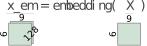

In [ ]:
# with tsensor.explain(fontname='Hack', dimfontname='Hack'):
#     x_em = embedding(X)

In [37]:
X.shape

(6, 9)

In [38]:
x_em.shape

TensorShape([6, 9, 128])

## Averaging across tokens

![](images/Emb6.png)

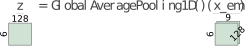

In [ ]:
# with tsensor.explain(fontname='Hack', dimfontname='Hack'):
#     z = GlobalAveragePooling1D()(x_em)

In [ ]:
z = GlobalAveragePooling1D()(x_em)      # averaging tensor across its column
z.shape

TensorShape([6, 128])